In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
!python --version

Python 3.9.0


In [3]:
# !pip install matplotlib

In [4]:
os.listdir()

['.ipynb_checkpoints', 'Electronic_sales_Sep2023-Sep2024.csv', 'hw3.ipynb']

In [5]:
df = pd.read_csv('Electronic_sales_Sep2023-Sep2024.csv')
df

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


Key Features:

Customer ID: Unique identifier for each customer.
Age: Age of the customer (numeric)
Gender: Gender of the customer (Male or Female)
Loyalty Member: (Yes/No) (Values change by time, so pay attention to who cancelled and who signed up)
Product Type: Type of electronic product sold (e.g., Smartphone, Laptop, Tablet)
SKU: a unique code for each product.
Rating: Customer rating of the product (1-5 stars) (Should have no Null Ratings)
Order Status: Status of the order (Completed, Cancelled)
Payment Method: Method used for payment (e.g., Cash, Credit Card, Paypal)
Total Price: Total price of the transaction (numeric)
Unit Price: Price per unit of the product (numeric)
Quantity: Number of units purchased (numeric)
Purchase Date: Date of the purchase (format: YYYY-MM-DD)
Shipping Type: Type of shipping chosen (e.g., Standard, Overnight, Express)
Add-ons Purchased: List of any additional items purchased (e.g., Accessories, Extended Warranty)
Add-on Total: Total price of add-ons purchased (numeric)

In [6]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Loyalty Member', 'Product Type', 'SKU',
       'Rating', 'Order Status', 'Payment Method', 'Total Price', 'Unit Price',
       'Quantity', 'Purchase Date', 'Shipping Type', 'Add-ons Purchased',
       'Add-on Total'],
      dtype='object')

In [7]:
columns = {k: k.lower().replace('-', '').replace(' ', '_') for k in  df.columns}
columns

{'Customer ID': 'customer_id',
 'Age': 'age',
 'Gender': 'gender',
 'Loyalty Member': 'loyalty_member',
 'Product Type': 'product_type',
 'SKU': 'sku',
 'Rating': 'rating',
 'Order Status': 'order_status',
 'Payment Method': 'payment_method',
 'Total Price': 'total_price',
 'Unit Price': 'unit_price',
 'Quantity': 'quantity',
 'Purchase Date': 'purchase_date',
 'Shipping Type': 'shipping_type',
 'Add-ons Purchased': 'addons_purchased',
 'Add-on Total': 'addon_total'}

In [8]:
df = df.rename(columns=columns)

In [9]:
df.describe(include="all")

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,addons_purchased,addon_total
count,20000.000000,20000.000000,19999,20000,20000,20000,20000.000000,20000,20000,20000.000000,20000.000000,20000.000000,20000,20000,15132,20000.000000
unique,NaN,NaN,2,2,5,10,NaN,2,6,NaN,NaN,NaN,366,5,75,NaN
top,NaN,NaN,Male,No,Smartphone,TBL345,NaN,Completed,Credit Card,NaN,NaN,NaN,2024-04-26,Standard,Extended Warranty,NaN
freq,NaN,NaN,10164,15657,5978,2062,NaN,13432,5868,NaN,NaN,NaN,88,6725,1701,NaN
mean,10483.526550,48.994100,NaN,NaN,NaN,NaN,3.093950,NaN,NaN,3180.133419,578.631867,5.485550,NaN,NaN,NaN,62.244848
std,5631.732525,18.038745,NaN,NaN,NaN,NaN,1.223764,NaN,NaN,2544.978675,312.274076,2.870854,NaN,NaN,NaN,58.058431
min,1000.000000,18.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,20.750000,20.750000,1.000000,NaN,NaN,NaN,0.000000
25%,5478.000000,33.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,1139.680000,361.180000,3.000000,NaN,NaN,NaN,7.615000
50%,10499.500000,49.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,2534.490000,463.960000,5.000000,NaN,NaN,NaN,51.700000
75%,15504.000000,65.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,4639.600000,791.190000,8.000000,NaN,NaN,NaN,93.842500


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            19999 non-null  object 
 3   loyalty_member    20000 non-null  object 
 4   product_type      20000 non-null  object 
 5   sku               20000 non-null  object 
 6   rating            20000 non-null  int64  
 7   order_status      20000 non-null  object 
 8   payment_method    20000 non-null  object 
 9   total_price       20000 non-null  float64
 10  unit_price        20000 non-null  float64
 11  quantity          20000 non-null  int64  
 12  purchase_date     20000 non-null  object 
 13  shipping_type     20000 non-null  object 
 14  addons_purchased  15132 non-null  object 
 15  addon_total       20000 non-null  float64
dtypes: float64(3), int64(4), object(9)
memor

# Задание 1 

Задание 1 (синтаксис)

Для каждого покупателя получите таблицу со столбцами:

• preferred_payment - самый частый метод оплаты (при ничьей зафиксируйте правило, например lexicographically первый);

• total_spent - сумма всех трат;

• addons_spent - сумма на дополнительные услуги и аксессуары;

• orders_count - число заказов.
 
 Отсортируйте по total_spent по убыванию и выведите топ-10.

Пример вывода (формат; числа зависят от датасета):

   customer_id  preferred_payment  total_spent  addons_spent  orders_count
 0         C042     Credit Card              15420.50        890.00             7
 1         C018     PayPal                     14810.00        450.00             5
 2         C103     Debit Card               13990.25       1200.00             6
 
 Пограничные случаи:

• Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.
 • Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
 • Покупатель без доп. услуг/аксессуаров - addons_spent = 0.
 • Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.

In [11]:
# Названия методов оплаты
df['payment_method'].unique()

array(['Credit Card', 'Paypal', 'Cash', 'Debit Card', 'Bank Transfer',
       'PayPal'], dtype=object)

In [12]:
# Анализ пропусков
df["payment_method"].isna().sum()

np.int64(0)

In [13]:
df['total_price'].isna().sum()


np.int64(0)

In [14]:
df['addon_total'].isna().sum()

np.int64(0)

In [15]:
# Количество уникальных потребителей
len(df['customer_id'].unique())

12136

In [16]:
# для расчета preferred_payment 
df_preferred = (
        df.groupby(["customer_id", "payment_method"])
        .size()
        .reset_index(name="cnt")
         # сортируем по cnt убыв., затем по Payment Method возр., берём первую строку.
        .sort_values(
            ["customer_id", "cnt", "payment_method"],
            ascending=[True, False, True]
        )
        .drop_duplicates("customer_id", keep="first")
        [["customer_id", "payment_method"]]
)
df_preferred

,customer_id,payment_method
0,1000,Credit Card
2,1002,Cash
4,1003,Cash
5,1004,Credit Card
6,1005,Debit Card
...,...,...
17144,19994,Bank Transfer
17145,19995,Credit Card
17146,19996,Bank Transfer
17149,19997,Bank Transfer


In [17]:
# Остальная статистика задания 1
df_stat = (
    df.groupby("customer_id")
    .agg(
        total_spent=("total_price", "sum"),
        addons_spent=("addon_total", "sum"),
        orders_count=("customer_id", "size")
    )
    .reset_index()
)
df_stat

,customer_id,total_spent,addons_spent,orders_count
0,1000,6279.42,66.30,2
1,1002,5020.60,60.16,2
2,1003,41.50,35.56,1
3,1004,83.00,65.78,1
4,1005,11779.11,75.33,2
...,...,...,...,...
12131,19994,5504.87,93.17,1
12132,19995,5394.56,0.00,1
12133,19996,27296.78,432.12,6
12134,19997,2528.26,101.34,1


In [18]:
# соеденяем две таблицы
df_task1 = (
    df_preferred.merge(df_stat, on="customer_id", how="left")
       .sort_values("total_spent", ascending=False)
       .reset_index(drop=True)
)
df_task1

,customer_id,payment_method,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,34563.70,495.19,7
1,16863,PayPal,33035.92,486.17,5
2,13813,Credit Card,31830.16,268.64,5
3,11476,PayPal,31077.61,301.59,5
4,12276,Bank Transfer,30961.18,329.07,6
...,...,...,...,...,...
12131,3720,Cash,20.75,0.00,1
12132,1094,Debit Card,20.75,0.00,1
12133,9525,Credit Card,20.75,0.00,1
12134,8570,Paypal,20.75,119.29,1


## Пограничные случаи задания 1

1. Покупатель с одним заказом - orders_count = 1, preferred_payment = единственный метод.

In [19]:
df_task1[df_task1['orders_count'] == 1]

,customer_id,payment_method,total_spent,addons_spent,orders_count
1133,19017,Credit Card,11396.80,0.00,1
1134,12986,PayPal,11396.80,38.98,1
1135,12611,Credit Card,11396.80,258.32,1
1136,19040,Bank Transfer,11396.80,28.42,1
1137,12779,PayPal,11396.80,88.07,1
...,...,...,...,...,...
12131,3720,Cash,20.75,0.00,1
12132,1094,Debit Card,20.75,0.00,1
12133,9525,Credit Card,20.75,0.00,1
12134,8570,Paypal,20.75,119.29,1


2. Два метода оплаты с одинаковой частотой - выберите один по зафиксированному правилу (укажите его в комментарии к коду).
При ничьей выбираем метод, лексикографически первый
сортируем по cnt убыв., затем по payment_method возр., берём первую строку
Оставил аналогичный коммент при формировании df_preferred

3. Покупатель без доп. услуг/аксессуаров - addons_spent = 0.

In [20]:
df_task1[df_task1['addons_spent'] == 0]

,customer_id,payment_method,total_spent,addons_spent,orders_count
136,17617,Bank Transfer,19058.36,0.0,3
183,14782,Credit Card,18087.43,0.0,3
272,13991,Bank Transfer,16548.40,0.0,2
285,11578,Credit Card,16326.00,0.0,2
307,13074,Bank Transfer,16115.26,0.0,2
...,...,...,...,...,...
12130,5587,Debit Card,20.75,0.0,1
12131,3720,Cash,20.75,0.0,1
12132,1094,Debit Card,20.75,0.0,1
12133,9525,Credit Card,20.75,0.0,1


Покупатель без доп. услуг/аксессуаров  не пропал

In [21]:
(df[df['customer_id'] == 17617])[['customer_id', 'addons_purchased', 'addon_total']]

,customer_id,addons_purchased,addon_total
17344,17617,NaN,0.0
17345,17617,NaN,0.0
17346,17617,NaN,0.0


In [22]:
df_task1[df_task1['customer_id'] == 17617]

,customer_id,payment_method,total_spent,addons_spent,orders_count
136,17617,Bank Transfer,19058.36,0.0,3


4. Пропуски в сумме или методе оплаты - обработайте (отфильтруйте или заполните) и кратко опишите решение в комментарии.

В датасете отсутствуют пропуски как как таковые, кроме столбцов gender, addons_purchased  

In [23]:
df_task1.head(10)

,customer_id,payment_method,total_spent,addons_spent,orders_count
0,16357,Bank Transfer,34563.70,495.19,7
1,16863,PayPal,33035.92,486.17,5
2,13813,Credit Card,31830.16,268.64,5
3,11476,PayPal,31077.61,301.59,5
4,12276,Bank Transfer,30961.18,329.07,6
5,13635,Credit Card,30260.36,480.73,5
6,12749,Credit Card,29394.56,619.43,5
7,15399,PayPal,29084.88,305.39,3
8,12319,Bank Transfer,27352.32,226.38,3
9,19996,Bank Transfer,27296.78,432.12,6


# Задача 2

In [24]:
df

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,addons_purchased,addon_total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


Обращаю внимание для формирования дохода надо брать успешно завершенные сделки. Поэтому предварительно посмотрим какие вообще есть статусы сделок

In [25]:
df['order_status'].unique()

array(['Cancelled', 'Completed'], dtype=object)

очедвидно отменненые сделки нужно исключить из отчета о доходах. Отменные сделки со статусом Canselled скорее являются "упущенной выгодой". Поэтому верным считаю отфильтровать от отменных сделок набор данных.

In [26]:
# Так же добавил в функцию clean
df = df[df["order_status"] == "Completed"].copy()

In [27]:
df

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,addons_purchased,addon_total
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
5,1004,41,Female,No,Smartphone,SKU1001,5,Completed,Credit Card,83.00,20.75,4,2024-05-26,Standard,"Impulse Item,Accessory",65.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,19995,69,Female,Yes,Laptop,LTP123,3,Completed,Credit Card,5394.56,674.32,8,2024-08-09,Same Day,NaN,0.00
19994,19996,27,Female,No,Smartphone,SMP234,5,Completed,Credit Card,3419.04,1139.68,3,2024-04-20,Same Day,NaN,0.00
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98


In [28]:
len(df['customer_id'].unique())

9466

In [29]:
12136 - 9466

2670

2670 - пользователей отменили сделку.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13432 entries, 1 to 19999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       13432 non-null  int64  
 1   age               13432 non-null  int64  
 2   gender            13431 non-null  object 
 3   loyalty_member    13432 non-null  object 
 4   product_type      13432 non-null  object 
 5   sku               13432 non-null  object 
 6   rating            13432 non-null  int64  
 7   order_status      13432 non-null  object 
 8   payment_method    13432 non-null  object 
 9   total_price       13432 non-null  float64
 10  unit_price        13432 non-null  float64
 11  quantity          13432 non-null  int64  
 12  purchase_date     13432 non-null  object 
 13  shipping_type     13432 non-null  object 
 14  addons_purchased  10145 non-null  object 
 15  addon_total       13432 non-null  float64
dtypes: float64(3), int64(4), object(9)
memory usa

нужно колонку purchase_date привести к типу данных даты

In [31]:
# Перенес в функцию clean
# df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors="coerce")

In [32]:
df[df['total_price']==0]

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,addons_purchased,addon_total


отсуствуют нулевые чеки

по прежнему имеются пропуски NaN в колонках addons_purchased и gender

In [33]:
pd.DataFrame(df.isna().sum().sort_values(ascending=False)).reset_index().rename(columns ={'index':'column',0:'Missing Values'})

,column,Missing Values
0,addons_purchased,3287
1,gender,1
2,age,0
3,customer_id,0
4,product_type,0
5,sku,0
6,rating,0
7,loyalty_member,0
8,order_status,0
9,payment_method,0


Очевидно доп. услуги с NaN ничего не должны стоить. Но можно проверить обратный случай, поискать доп. услуги с не NaN значением. т.е. те где есть доп. услуга но по какой-то причине без положительной стоимости.

In [34]:
df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors="coerce")

### Функция clean

In [35]:
def clean(df):
    df = df[df["order_status"] == "Completed"].copy()
    df["purchase_date"] = pd.to_datetime(df["purchase_date"], errors="coerce")
    df = df[df["total_price"] > 0].copy()
    return df

In [36]:
df = clean(df)

### Функция build_metrics

In [37]:
def build_metrics(df):
    metrics = {}
    
    if df.empty:
            metrics['revenue_by_shipping'] = pd.DataFrame(columns=["shipping_type", "revenue"])
            metrics['revenue_by_product'] = pd.DataFrame(columns=["product_type", "revenue"])
            metrics['addons_by_month'] = pd.DataFrame(columns=["month", "addons_revenue"])
            metrics['addons_by_quarter'] = pd.DataFrame(columns=["quarter", "addons_revenue"])
            metrics['cohort_customers'] = pd.DataFrame(
                index=pd.PeriodIndex([], freq="M", name="cohort"),
                columns=pd.Index([0, 1, 2, 3], name="month_life"),
                dtype="float64",
            )
            metrics['cohort_revenue'] = pd.DataFrame(
                index=pd.PeriodIndex([], freq="M", name="cohort"),
                columns=pd.Index([0, 1, 2, 3], name="month_life"),
                dtype="float64",
            )
            return metrics
        
    metrics['revenue_by_shipping'] =  (
        df.groupby("shipping_type")
        .agg(
            revenue=("total_price", "sum")
        )
        .reset_index()
    )
    metrics['revenue_by_product'] = (
        df.groupby("product_type")
        .agg(
            revenue=("total_price", "sum")
        )
        .reset_index()
    )
    metrics['addons_by_month'] =  (
        df.assign(month=df["purchase_date"].dt.to_period("M").astype(str))
              .groupby("month", as_index=False)["addon_total"]
              .sum()
              .rename(columns={"addon_total": "addons_revenue"})
              .sort_values("month")
              .reset_index(drop=True)
    )
    metrics['addons_by_quarter'] = (
        df.assign(quarter=df["purchase_date"].dt.to_period("Q").astype(str))
          .groupby("quarter", as_index=False)["addon_total"]
          .sum()
          .rename(columns={"addon_total": "addons_revenue"})
          .sort_values("quarter")
          .reset_index(drop=True)
    )
    metrics['cohort_customers'] = (
        df.assign(_c=lambda d: d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M"),
                  _l=lambda d: (d["purchase_date"].dt.to_period("M") - d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")).apply(lambda p: p.n))
          .query("0 <= _l <= 3")
          .pivot_table(index="_c", columns="_l", values="customer_id", aggfunc="nunique")
          .reindex(columns=[0, 1, 2, 3])
          .rename_axis(index="cohort", columns="month_life")
    )
    metrics['cohort_revenue'] = (
        df.assign(_c=lambda d: d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M"),
                  _l=lambda d: (d["purchase_date"].dt.to_period("M") - d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")).apply(lambda p: p.n),
                  _r=lambda d: d["total_price"].fillna(0) + d["addon_total"].fillna(0))
          .query("0 <= _l <= 3")
          .pivot_table(index="_c", columns="_l", values="_r", aggfunc="sum")
          .reindex(columns=[0, 1, 2, 3])
          .rename_axis(index="cohort", columns="month_life")
    )
    return metrics

In [38]:
metrics = build_metrics(df)

In [39]:
metrics

{'revenue_by_shipping':   shipping_type      revenue
 0     Expedited   8430385.58
 1       Express   5632093.35
 2     Overnight   5887722.52
 3      Same Day   8292376.50
 4      Standard  14387037.62,
 'revenue_by_product':   product_type      revenue
 0   Headphones   2734651.00
 1       Laptop   8365905.25
 2   Smartphone  14407835.84
 3   Smartwatch   9398591.23
 4       Tablet   7722632.25,
 'addons_by_month':       month  addons_revenue
 0   2023-09         5337.61
 1   2023-10        26153.21
 2   2023-11        24453.33
 3   2023-12        22750.23
 4   2024-01        93254.95
 5   2024-02        80253.72
 6   2024-03        84713.93
 7   2024-04        82294.06
 8   2024-05        89374.18
 9   2024-06        84648.60
 10  2024-07        88811.55
 11  2024-08        87861.11
 12  2024-09        65688.76,
 'addons_by_quarter':   quarter  addons_revenue
 0  2023Q3         5337.61
 1  2023Q4        73356.77
 2  2024Q1       258222.60
 3  2024Q2       256316.84
 4  2024Q3       

## Метрики

ВНИМАНИЕ! Отклоненные сделки уже вычищены. Отчет недополученного дохода не формирую в рамках ДЗ, но при обычной работе, как минимум бы обсудил этот момент с заказчиком отчета.

### Доход по методу доставки

In [40]:
# Перенес в функцию build_metrics
# revenue_by_shipping = (
#     df.groupby("shipping_type")
#     .agg(
#         revenue=("total_price", "sum")
#     )
#     .reset_index()
# )
# revenue_by_shipping
metrics['revenue_by_shipping']

,shipping_type,revenue
0,Expedited,8430385.58
1,Express,5632093.35
2,Overnight,5887722.52
3,Same Day,8292376.50
4,Standard,14387037.62


### Доход по типу продукта

In [41]:
# Перенес в функцию build_metrics
# revenue_by_product = (
#     df.groupby("product_type")
#     .agg(
#         revenue=("total_price", "sum")
#     )
#     .reset_index()
# )
# revenue_by_product
metrics['revenue_by_product']

,product_type,revenue
0,Headphones,2734651.00
1,Laptop,8365905.25
2,Smartphone,14407835.84
3,Smartwatch,9398591.23
4,Tablet,7722632.25


### Доход по доп. услугам: по месяцам и по кварталам;

In [42]:
# Перенес в функцию build_metrics
# addons_by_month = (
#     df.assign(month=df["purchase_date"].dt.to_period("Q").astype(str))
#       .groupby("month", as_index=False)["addon_total"]
#       .sum()
#       .rename(columns={"addon_total": "addons_revenue"})
#       .sort_values("quarter")
#       .reset_index(drop=True)
# )
# addons_by_month
metrics['addons_by_month']

,month,addons_revenue
0,2023-09,5337.61
1,2023-10,26153.21
2,2023-11,24453.33
3,2023-12,22750.23
4,2024-01,93254.95
5,2024-02,80253.72
6,2024-03,84713.93
7,2024-04,82294.06
8,2024-05,89374.18
9,2024-06,84648.60


In [43]:
# Перенес в функцию build_metrics
# addons_by_quarter = (
#     df.assign(quarter=df["purchase_date"].dt.to_period("Q").astype(str))
#       .groupby("quarter", as_index=False)["addon_total"]
#       .sum()
#       .rename(columns={"addon_total": "addons_revenue"})
#       .sort_values("quarter")
#       .reset_index(drop=True)
# )
# addons_by_quarter
metrics['addons_by_quarter']

,quarter,addons_revenue
0,2023Q3,5337.61
1,2023Q4,73356.77
2,2024Q1,258222.60
3,2024Q2,256316.84
4,2024Q3,242361.42


## Когортный анализ

In [44]:
# Перенес в функцию build_metrics
# cohort_customers = (
#     df.assign(_c=lambda d: d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M"),
#               _l=lambda d: (d["purchase_date"].dt.to_period("M") - d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")).apply(lambda p: p.n))
#       .query("0 <= _l <= 3")
#       .pivot_table(index="_c", columns="_l", values="customer_id", aggfunc="nunique")
#       .reindex(columns=[0, 1, 2, 3])
#       .rename_axis(index="cohort", columns="month_life")
# )
# cohort_customers
metrics['cohort_customers']

month_life,0,1,2,3
cohort,,,,
2023-09,121.0,11.0,12.0,12.0
2023-10,581.0,27.0,35.0,36.0
2023-11,482.0,21.0,39.0,24.0
2023-12,442.0,27.0,16.0,23.0
2024-01,1236.0,72.0,88.0,88.0
2024-02,1029.0,65.0,71.0,75.0
2024-03,1028.0,77.0,71.0,72.0
2024-04,907.0,76.0,73.0,63.0
2024-05,906.0,53.0,66.0,50.0


In [45]:
# Перенес в функцию build_metrics
# cohort_revenue = (
#     df.assign(_c=lambda d: d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M"),
#               _l=lambda d: (d["purchase_date"].dt.to_period("M") - d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")).apply(lambda p: p.n),
#               _r=lambda d: d["total_price"].fillna(0) + d["addon_total"].fillna(0))
#       .query("0 <= _l <= 3")
#       .pivot_table(index="_c", columns="_l", values="_r", aggfunc="sum")
#       .reindex(columns=[0, 1, 2, 3])
#       .rename_axis(index="cohort", columns="month_life")
# )
# cohort_revenue
metrics['cohort_revenue']

month_life,0,1,2,3
cohort,,,,
2023-09,288973.36,33966.24,27171.95,33728.93
2023-10,1547512.83,57546.84,105708.66,105318.56
2023-11,1329851.04,51831.74,120410.29,49399.43
2023-12,1141503.77,70631.39,51051.53,66268.75
2024-01,4300575.58,224810.52,363311.35,367531.56
2024-02,3551138.51,237765.99,258807.13,276145.83
2024-03,3492721.17,309227.62,249389.13,247959.27
2024-04,3176736.50,255450.10,270533.88,246163.28
2024-05,3129140.50,184409.51,242471.91,186356.86


## Графики

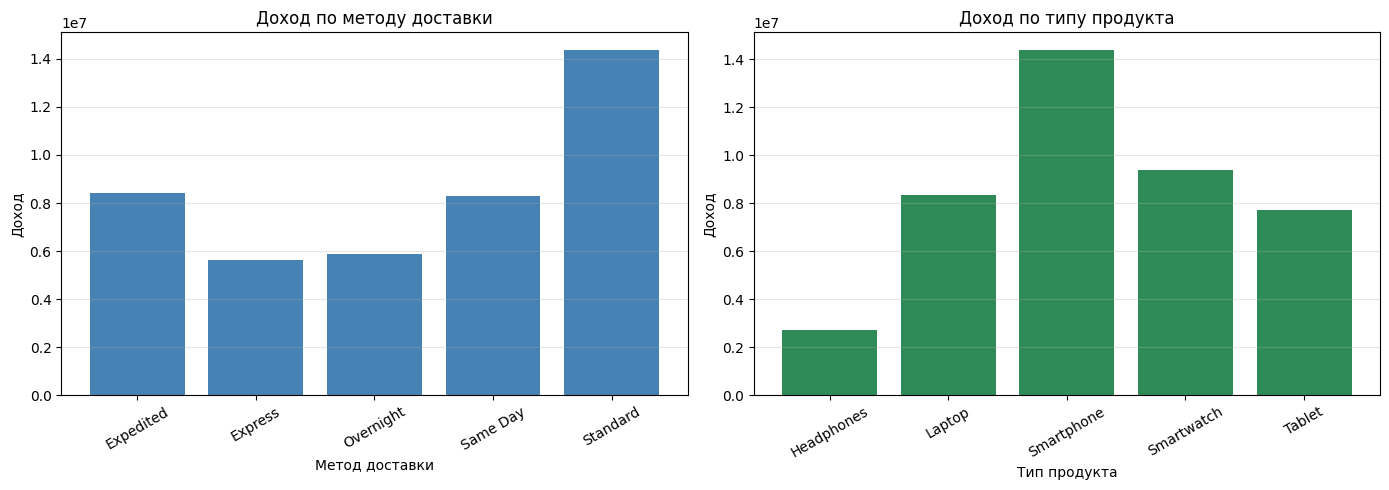

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- по доставке ---
# ship = revenue_by_shipping
ship = metrics['revenue_by_shipping']
axes[0].bar(ship["shipping_type"], ship["revenue"], color="steelblue")
axes[0].set_title("Доход по методу доставки")
axes[0].set_xlabel("Метод доставки")
axes[0].set_ylabel("Доход")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

# --- по типу продукта ---
prod = metrics['revenue_by_product']
axes[1].bar(prod["product_type"], prod["revenue"], color="seagreen")
axes[1].set_title("Доход по типу продукта")
axes[1].set_xlabel("Тип продукта")
axes[1].set_ylabel("Доход")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

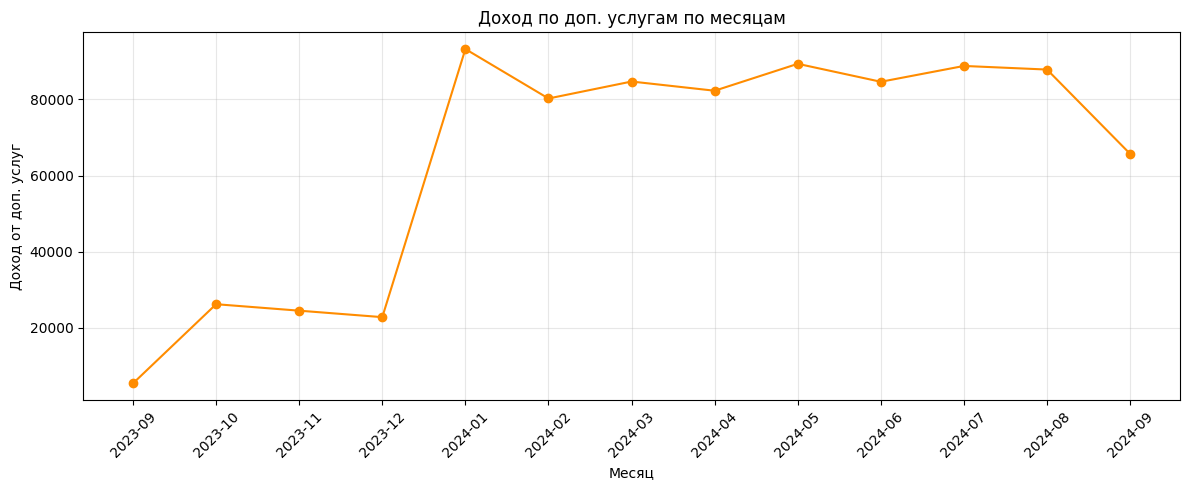

In [47]:
fig, ax = plt.subplots(figsize=(12, 5))

# m = addons_by_month
m = metrics['addons_by_month']
ax.plot(m["month"], m["addons_revenue"], marker="o", color="darkorange")

ax.set_title("Доход по доп. услугам по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Доход от доп. услуг")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

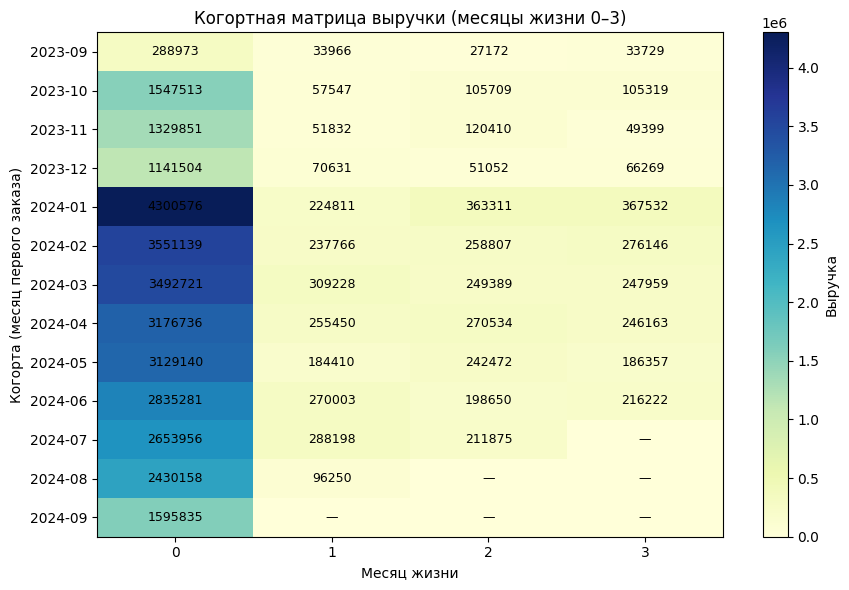

In [48]:
fig, ax = plt.subplots(figsize=(9, 6))

# mat = cohort_revenue
mat = metrics['cohort_revenue']
# NaN -> 0 для отображения; исходные NaN оставим как «нет данных»
data = mat.fillna(0).values
rows = mat.index.astype(str).tolist()
cols = [str(c) for c in mat.columns]

im = ax.imshow(data, aspect="auto", cmap="YlGnBu")

# подписи осей
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)

ax.set_title("Когортная матрица выручки (месяцы жизни 0–3)")
ax.set_xlabel("Месяц жизни")
ax.set_ylabel("Когорта (месяц первого заказа)")

# числа в ячейках
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isnan(mat.values[i, j]):
            txt = "—"
        else:
            txt = f"{data[i, j]:.0f}"
        ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Выручка")

plt.tight_layout()
plt.show()

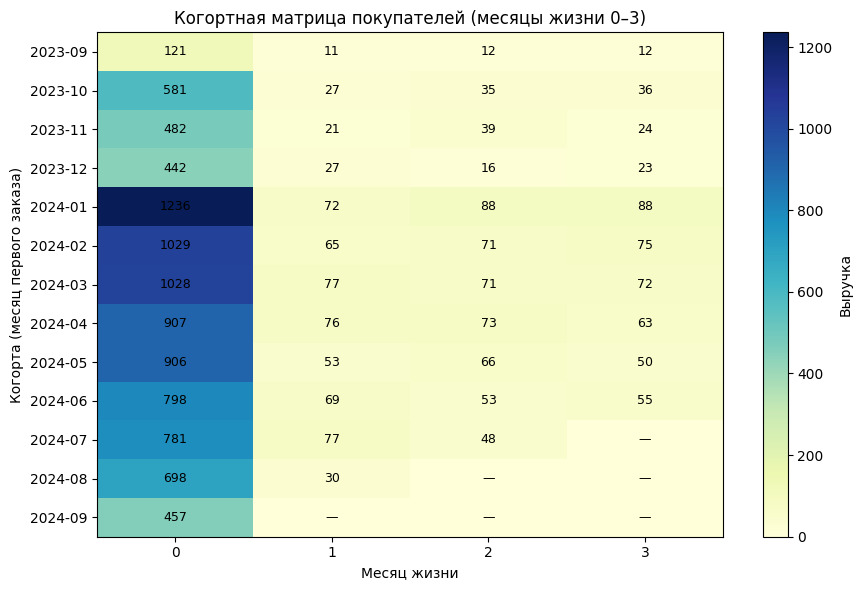

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

# mat = cohort_customers
mat = metrics['cohort_customers']
# NaN -> 0 для отображения; исходные NaN оставим как «нет данных»
data = mat.fillna(0).values
rows = mat.index.astype(str).tolist()
cols = [str(c) for c in mat.columns]

im = ax.imshow(data, aspect="auto", cmap="YlGnBu")

# подписи осей
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)

ax.set_title("Когортная матрица покупателей (месяцы жизни 0–3)")
ax.set_xlabel("Месяц жизни")
ax.set_ylabel("Когорта (месяц первого заказа)")

# числа в ячейках
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isnan(mat.values[i, j]):
            txt = "—"
        else:
            txt = f"{data[i, j]:.0f}"
        ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Выручка")

plt.tight_layout()
plt.show()

## Выводы

1. Организация не способна удерживать клиентов
2. Вероятно поменялась с начала 2024 года политика или способы навязывания доп. услуг. Так как заметенет резкий рост доходов по доп. услугам.
3. 

Доходы по методам доставки и по типу товаров, не достаточны для принятия управленческих решений. Нужно сопоставлять с расходами и эффектами. Например, сколько добавит прибыли если заместить одну доставку на другую, для того чтобы действительно понять, что что-то выгодно, а что-то нет.

## Пограничные случаи задания 2

1. Заказы с отрицательной или нулевой ценой - не должны попадать в доход после clean.
Учтено в функции clean

2. Покупатель с одним заказом - в когортной матрице заполнен только месяц 0.

In [50]:
# Покупатели сделавшие 1 заказ(завершенный заказ)
df_count_order = df.groupby('customer_id').size().reset_index(name="cnt")
df_count_order

,customer_id,cnt
0,1000,1
1,1002,2
2,1003,1
3,1004,1
4,1005,2
...,...,...
9461,19990,1
9462,19991,2
9463,19995,1
9464,19996,3


In [51]:
df_count_order_eq_1 = df_count_order[df_count_order['cnt'] == 1]
df_count_order_eq_1 = df[df['customer_id'].isin(df_count_order_eq_1['customer_id'])]
df_count_order_eq_1

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,addons_purchased,addon_total
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
5,1004,41,Female,No,Smartphone,SKU1001,5,Completed,Credit Card,83.00,20.75,4,2024-05-26,Standard,"Impulse Item,Accessory",65.78
12,1008,66,Female,No,Smartwatch,SKU1003,3,Completed,Cash,3379.32,844.83,4,2023-09-25,Express,"Extended Warranty,Impulse Item,Extended Warranty",65.85
13,1011,72,Male,No,Smartphone,SKU1004,2,Completed,Credit Card,7911.90,791.19,10,2024-07-07,Standard,"Accessory,Accessory,Accessory",70.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19984,19984,62,Male,No,Laptop,LTP123,1,Completed,PayPal,674.32,674.32,1,2024-09-22,Expedited,"Extended Warranty, Accessory",135.71
19985,19988,56,Male,No,Smartphone,SMP234,4,Completed,Bank Transfer,7977.76,1139.68,7,2024-06-12,Standard,"Extended Warranty, Impulse Item, Extended Warr...",216.94
19986,19990,24,Female,No,Smartphone,SMP234,5,Completed,PayPal,9117.44,1139.68,8,2024-05-05,Standard,"Impulse Item, Accessory",113.56
19991,19995,69,Female,Yes,Laptop,LTP123,3,Completed,Credit Card,5394.56,674.32,8,2024-08-09,Same Day,NaN,0.00


In [52]:
df_cohort_count_order_eq_1 = (
    df_count_order_eq_1.assign(_c=lambda d: d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M"),
              _l=lambda d: (d["purchase_date"].dt.to_period("M") - d.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")).apply(lambda p: p.n))
      .query("0 <= _l <= 3")
      .pivot_table(index="_c", columns="_l", values="customer_id", aggfunc="nunique")
      .reindex(columns=[0, 1, 2, 3])
      .rename_axis(index="cohort", columns="month_life")
)
df_cohort_count_order_eq_1

month_life,0,1,2,3
cohort,,,,
2023-09,49,NaN,NaN,NaN
2023-10,301,NaN,NaN,NaN
2023-11,262,NaN,NaN,NaN
2023-12,265,NaN,NaN,NaN
2024-01,663,NaN,NaN,NaN
2024-02,589,NaN,NaN,NaN
2024-03,657,NaN,NaN,NaN
2024-04,581,NaN,NaN,NaN
2024-05,678,NaN,NaN,NaN


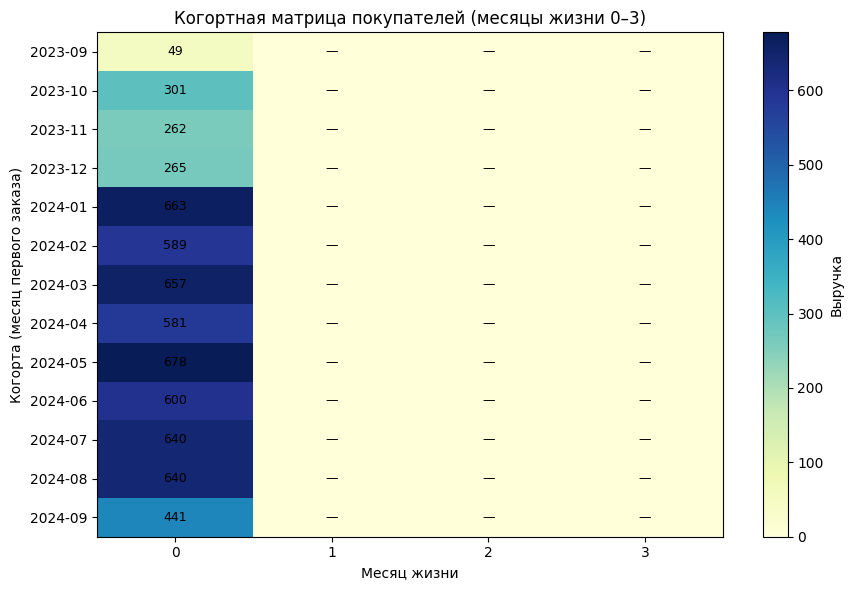

In [53]:
fig, ax = plt.subplots(figsize=(9, 6))

# mat = cohort_customers
mat = df_cohort_count_order_eq_1
# NaN -> 0 для отображения; исходные NaN оставим как «нет данных»
data = mat.fillna(0).values
rows = mat.index.astype(str).tolist()
cols = [str(c) for c in mat.columns]

im = ax.imshow(data, aspect="auto", cmap="YlGnBu")

# подписи осей
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)

ax.set_title("Когортная матрица покупателей (месяцы жизни 0–3)")
ax.set_xlabel("Месяц жизни")
ax.set_ylabel("Когорта (месяц первого заказа)")

# числа в ячейках
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if np.isnan(mat.values[i, j]):
            txt = "—"
        else:
            txt = f"{data[i, j]:.0f}"
        ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)

# colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Выручка")

plt.tight_layout()
plt.show()

3. Месяц без доп. услуг - в addons_by_month строка с 0 или отсутствие месяца (выберите и зафиксируйте поведение).

In [54]:
df_addons_by_month = metrics['addons_by_month']
df_addons_by_month[df_addons_by_month['addons_revenue'] ==0]

,month,addons_revenue


Месяц с 0 доп. услуг отсутствует

4. Пустой датасет после очистки → функции не падают, возвращают пустые таблицы.

Предположим после очистки вернулся пустой датафрейм, с правильными названиями колонок, но отсутствуют строки данных. Для примера возьму срез за пределами датафрейма.

In [55]:
df[22222:]

,customer_id,age,gender,loyalty_member,product_type,sku,rating,order_status,payment_method,total_price,unit_price,quantity,purchase_date,shipping_type,addons_purchased,addon_total


In [56]:
emty_metrics = build_metrics(df[22222:])
emty_metrics

{'revenue_by_shipping': Empty DataFrame
 Columns: [shipping_type, revenue]
 Index: [],
 'revenue_by_product': Empty DataFrame
 Columns: [product_type, revenue]
 Index: [],
 'addons_by_month': Empty DataFrame
 Columns: [month, addons_revenue]
 Index: [],
 'addons_by_quarter': Empty DataFrame
 Columns: [quarter, addons_revenue]
 Index: [],
 'cohort_customers': Empty DataFrame
 Columns: [0, 1, 2, 3]
 Index: [],
 'cohort_revenue': Empty DataFrame
 Columns: [0, 1, 2, 3]
 Index: []}

In [57]:
emty_metrics['cohort_revenue']

month_life,0,1,2,3
cohort,,,,


In [58]:
emty_metrics['revenue_by_shipping']

,shipping_type,revenue
